# CNN with Keras

> **Unlike the previous notebooks, this one uses TensorFlow/Keras instead of pure NumPy, allowing us to focus on CNN architecture and image classification rather than reimplementing the underlying computations.**

## Objective

Build and train a Convolutional Neural Network (CNN) using TensorFlow/Keras for image classification on the MNIST dataset.

## Why Convolutional Neural Networks?

Artificial Neural Networks (ANNs) can classify images, but they ignore the spatial structure of pixels and require a large number of parameters.

Convolutional Neural Networks (CNNs) address these limitations by using convolutional filters to automatically learn local features while significantly reducing the number of trainable parameters.

## Topics

- MNIST dataset preprocessing
- Convolutional layers
- Pooling layers
- CNN architecture
- Model training
- Prediction
- Model evaluation

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from keras import models
from keras import layers
from keras.utils import to_categorical
from keras.datasets import mnist

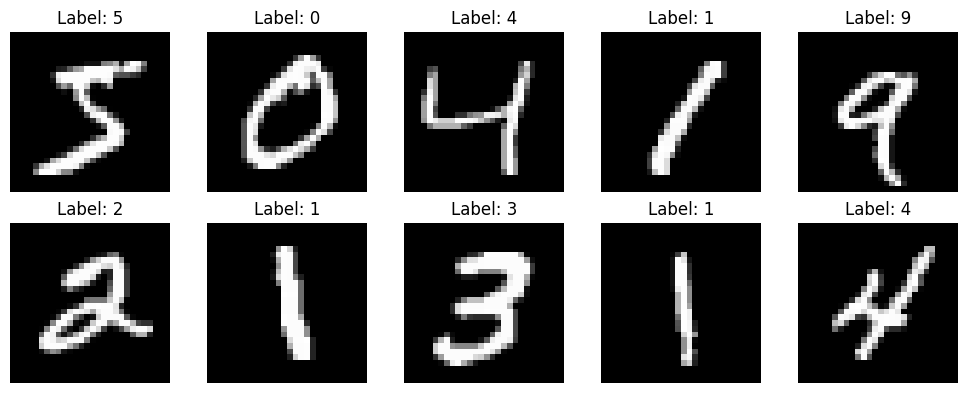

In [2]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
fig, axes = plt.subplots(2, 5, figsize=(10, 4))  
axes = axes.ravel() 

for i in range(10):
    axes[i].imshow(train_images[i], cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"Label: {train_labels[i]}")

plt.tight_layout()
plt.show()

In [3]:
train_images_cnn = train_images.reshape((60000, 28, 28, 1)).astype("float32") / 255
test_images_cnn = test_images.reshape((10000, 28, 28, 1)).astype("float32") / 255

train_labels_cnn = to_categorical(train_labels)
test_labels_cnn = to_categorical(test_labels)

In [8]:
def build_cnn(input_shape=(28,28,1), activation='relu', output_activation='softmax'):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3,3), activation=activation, input_shape=input_shape))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(64, (3,3), activation=activation))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(64, (3,3), activation=activation))
    # Data at this stage is in matrix form. We will convert it to vector form to feed to a fully connected network (FCN).
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation=activation))
    # This is the final layer. Hence, the outputs will be 10 corresponding to the 10 digits (0 to 9).
    model.add(layers.Dense(10, activation=output_activation))
    return model


In [9]:
def compile_and_train(model, optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"]):
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    history = model.fit(train_images_cnn, train_labels_cnn, epochs=30, batch_size=50, validation_split=0.2)
    return history

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 3, 3, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9415 - loss: 0.1845 - val_accuracy: 0.9799 - val_loss: 0.0692
Epoch 2/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9847 - loss: 0.0490 - val_accuracy: 0.9818 - val_loss: 0.0593
Epoch 3/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9897 - loss: 0.0337 - val_accuracy: 0.9889 - val_loss: 0.0419
Epoch 4/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9918 - loss: 0.0257 - val_accuracy: 0.9899 - val_loss: 0.0382
Epoch 5/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9935 - loss: 0.0198 - val_accuracy: 0.9896 - val_loss: 0.0398
Epoch 6/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9951 - loss: 0.0161 - val_accuracy: 0.9866 - val_loss: 0.0501
Epoch 7/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9962 - loss: 0.0123 - val_accuracy: 0.9910 - val_loss: 0.0422
Epoch 8/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9968 - loss: 0.0102 - val_accuracy: 0.

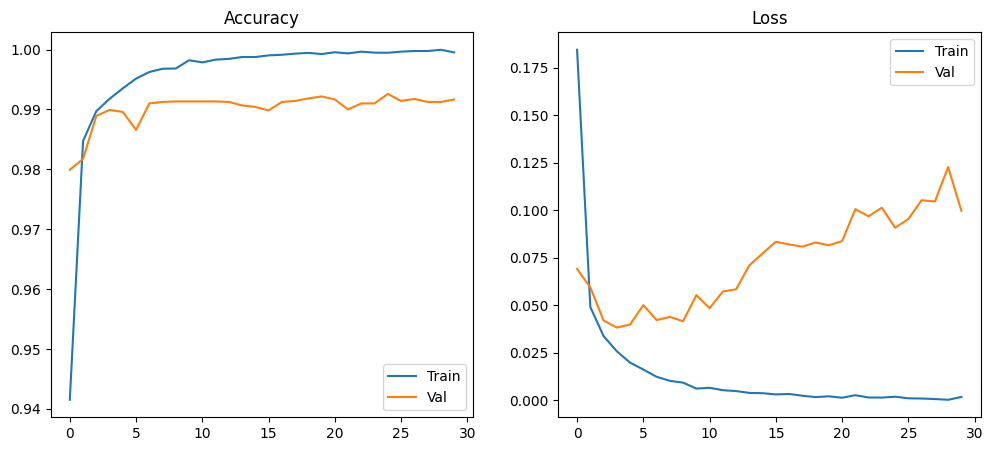

In [10]:
model_cnn = build_cnn()

model_cnn.summary()

history = compile_and_train(model_cnn)
plt.figure(figsize=(12, 5))

test_loss_cnn, test_acc_cnn = model_cnn.evaluate(test_images_cnn, test_labels_cnn)
print("Test accuracy:", test_acc_cnn * 100)

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()

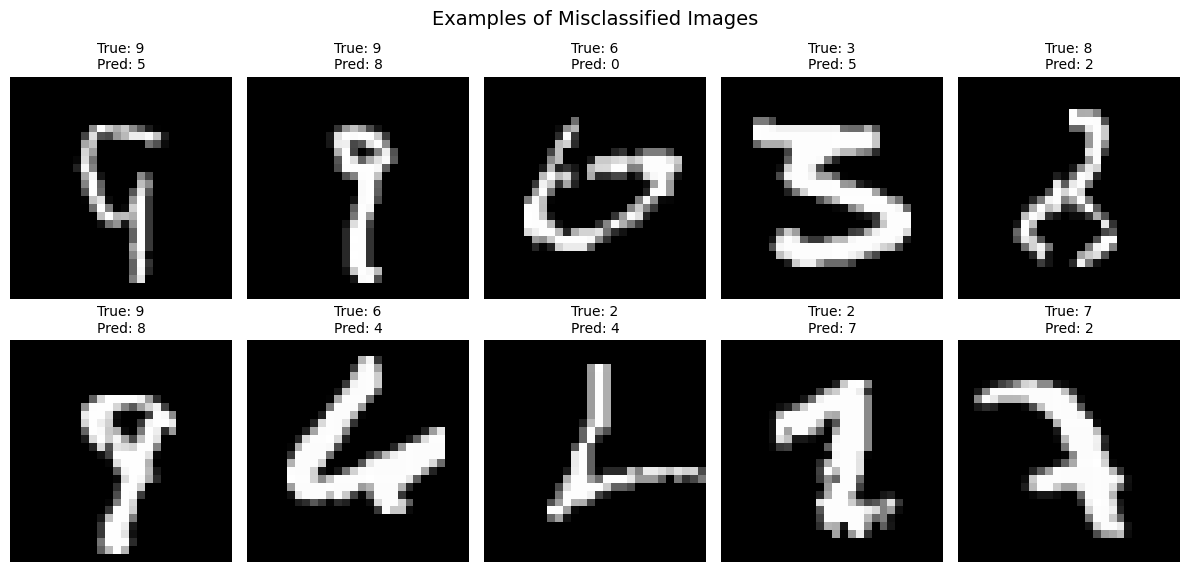

In [13]:
predictions = model_cnn.predict(test_images, verbose=0)

predicted_labels = np.argmax(predictions, axis=1)

misclassified_indices = np.where(predicted_labels != test_labels)[0]

plt.figure(figsize=(12, 6))

for i, idx in enumerate(misclassified_indices[:10]):

    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[idx], cmap="gray")
    plt.title(
        f"True: {test_labels[idx]}\nPred: {predicted_labels[idx]}",
        fontsize=10
    )

    plt.axis("off")
plt.suptitle("Examples of Misclassified Images", fontsize=14)
plt.tight_layout()
plt.show()

A Convolutional Neural Network was successfully built using TensorFlow/Keras and achieved a **Test Accuracy of 99,911%** on the MNIST dataset. 
This notebook marks the transition from implementing algorithms from scratch with NumPy to using a deep learning framework for building more powerful image classification models.